In [1]:
%pip install casadi

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import casadi as ca
import numpy as np
import scipy as sp

# 1. Étude du problème d’optimisation #
**Question 1 :** Justifier la forme de la dynamique de charge (1).

**Réponse :**
$\newline$


L'état de charge de la batterie à l'instant $i+1$ pour le véhicule $j$ correspond à l'état de charge à l'instant $i$ (i.e. $Q_{j,i}$) augmenté de la charge apportée pendant la durée $\Delta t$ (entre $t_{i}$ et $t_{i+1}$). 
$\newline$
Cette charge apportée correspond à  $\Delta t \beta_{j}P_{j,i}$ où : $∆t$ correspond au temps de charge, $P_{j,i}$ correspond à la puissance de la station de charge $j$ et $\beta_{j}$ correspond au rendement de la charge, c'est-à-dire au taux de conversion de l'énergie de la zone de charge vers la batterie. 

**Question 2 :** Formuler le problème d’optimisation à résoudre sous la forme :

$$\begin{aligned}
    \min_{x} \quad & f(x) \\
    \text{tel que} \quad & c_{eq}(x) = 0, \\
    & c_{in}(x) \leq 0
\end{aligned} \tag{5}$$          

On précisera les variables de décision $x$, leur nombre $n$, les contraintes $c_{eq}$ et $c_{in}$ ainsi que la fonction
objectif $f$ à minimiser.*

**Réponse :**
$\newline$


On prend $P_{j,i}$ pour $i\in\{0, …, N\}$ et $j\in\{1, …, N_{v}\}$ et $Q_{j,i}$ pour $i\in\{0, …, N\}$ et $j\in\{1, …, N_{v}\}$, comme variables de décision. 
$\newline$
On a donc $\boxed{n = 2 \: (N + 1) \cdot N_{v}}$ variables de décision.
$\newline$
La quantité qu'on cherche à minimiser est la suivante : $$\Delta t\sum\limits_{j=1}^{N_{v}} \sum\limits_{i=0}^N c_{i}P_{j, i}\newline$$
$x$ étant le vecteur colonne suivant : $$\boxed{x = \begin{pmatrix} \mathbf{P}_{0} \\ \mathbf{P}_{1} \\ \vdots \\ \mathbf{P}_{N} \\ \mathbf{Q}_{0} \\ \mathbf{Q}_{1} \\ \vdots \\ \mathbf{Q}_{N} \end{pmatrix} \quad \text{avec} \quad \mathbf{P}_{i} = \begin{pmatrix} P_{1,i} \\ P_{2,i} \\ \vdots \\ P_{N_v,i} \end{pmatrix} \quad \text{et} \quad \mathbf{Q}_{i} = \begin{pmatrix} Q_{1,i} \\ Q_{2,i} \\ \vdots \\ Q_{N_v,i} \end{pmatrix} \quad \text{pour} \quad i\in\{0, …, N\}}$$
On peut donc poser : $$\boxed{f~:~x\mapsto \Delta t\sum\limits_{j=1}^{N_{v}} \sum\limits_{i=0}^N c_{i}P_{j,i}}$$
$\newline$
Les contraintes sont les suivantes :

- $\forall~j \in \{1, …, N_{v}\}, \forall~ i \in \{0, …, N-1\}$ tel que $t_{i}\in [t_{j}^{in}, t_{j}^f], ~ Q_{j, i+1} - Q_{j, i} - \Delta t\beta_{j} P_{j, i}= 0$ ($\sum\limits_{j=1}^{N_{v}} \frac{t_{j}^f-t_{j}^{in}}{\Delta t}$ contraintes) (aussi vrai pour les instants $t_{i}\notin [t_{j}^{in}, t_{j}^f]$, puisque dans ce cas $P_{j,i} = 0$, et on convient que si $t_i < t_j^{in}, Q_{j,i} = Q_j^{in}$, et si $t_i > t_j^f, Q_{j,i} = Q_j^f$)

- $\forall~j \in \{1, …, N_{v}\}, Q_{j, i_{j0}} = Q_j^{in}$ et $ Q_{j, i_{jf}} = Q_j^{f}$ avec $i_{j0} = \frac{t_j^{in}}{\Delta t}$ et $i_{jf} = \frac{t_j^{f}}{\Delta t}$
($2 \cdot N_{v}$ contraintes)

- $\forall~ i \in \{0, …, N\}, ~ \sum\limits_{j=1}^{N_{v}} P_{j,i} - \bar{P} \leq 0$ ($N + 1$ contraintes)

- $\forall~j \in \{1, …, N_{v}\} ,~\forall~ i \in \{0, …, N\},~ - P_{j,i} \leq 0$ ($(N + 1) \cdot N_{v}$ contraintes)

- $\forall~j \in \{1, …, N_{v}\} ,~\forall~ i \in \{0, …, N\},~ - Q_{j,i} \le 0$ et $Q_{j,i} - \bar{Q} \leq 0$ ($2 \: (N + 1) \cdot N_{v}$ contraintes)

On peut donc poser : $$\boxed{c_{eq}~:~x\mapsto \begin{pmatrix} Q_{1, 1} - Q_{1, 0} - \Delta t\beta_{1} P_{1, 0} \\ \vdots \\ Q_{N_v, N} - Q_{N_v, N-1} - \Delta t\beta_{N_v} P_{N_v, N-1} \\ Q_{1, i_{10}} - Q_1^{in} \\ Q_{1, i_{1f}} - Q_1^{f} \\ \vdots \\ Q_{N_v, i_{N_v0}} - Q_{N_v}^{in} \\ Q_{N_v, i_{N_vf}} - Q_{N_v}^{f} \end{pmatrix}}$$
et
$$\boxed{c_{in}~:~x\mapsto \begin{pmatrix} \sum\limits_{j=1}^{N_{v}} P_{j,0} - \bar{P} \\ \vdots \\ \sum\limits_{j=1}^{N_{v}} P_{j,N} - \bar{P} \\ - P_{1,0} \\ \vdots \\ - P_{N_v,N} \\ - Q_{1,0} \\ \vdots \\ - Q_{N_v,N} \\ Q_{1,0} - \bar{Q} \\ \vdots \\ Q_{N_v,N} - \bar{Q} \end{pmatrix}}$$

Le problème d'optimisation à résoudre est alors le suivant : $$\boxed{\begin{aligned}
    \min_{x} \quad & f(x) \\
    \text{tel que} \quad & c_{eq}(x) = 0, \\
    & c_{in}(x) \leq 0
\end{aligned}}$$

**Question 3 :** Etudier la convexité de ce problème. Appartient-il à une famille particulière de problèmes d’optimisation ?

**Réponse :**
$\newline$

La fonction $f$ que l'on cherche à minimiser est linéaire, elle est donc bien évidemment convexe. Ce problème appartient donc à la famille des problèmes d'optimisation convexe sous contraintes.

**-> PRÉCISER**

# 2. Identification du paramètre $\beta$ #
**Question 4 :** On cherche à identifier le paramètre $\beta$ à partir de ces essais, connaissant la charge maximale atteignable
$\bar{Q}$ (qui est elle simple à déterminer) et la tension secteur $U_{sec} = 230V$, reliant puissance et intensité.
Formuler le problème de moindres carrés correspondant à l’identification de $\beta$.

**Réponse :**

Le document _'data_battery.csv'_ nous fournit le facteur de charge à l'instant $i$ $SOC_{i}= \displaystyle \frac{Q_{i}}{\bar{Q}}$ et l'intensité à l'instant $i$ $I_{i}$ également. L'équation  $Q_{j, i+1} - Q_{j, i} - \Delta t\beta_{j} P_{j, i}= 0$ devient :
$$ SOC_{i+1}\bar{Q}-SOC_{i}\bar{Q} = \Delta t\beta U_{sec}I_{i}$$

En notant $\Delta SOC_{i} =SOC_{i+1}-SOC_{i}$ on a : 
$$ \Delta SOC_{i} = \frac{\Delta t\beta U_{sec}I_{i}}{\bar{Q}}$$

Grâce à _'data_battery.csv'_ on peut calculer facilement $\Delta SOC_{i}^{expérimental}$.
$\newline$
Pour le problème de moindres carrés on considère la fonction $g$ suivante :
$$g(\beta) = \sum\limits_{i=1}^{N} (\Delta SOC_{i}^{expérimental} - \frac{\Delta t\beta U_{sec}I_{i}}{\bar{Q}})^2$$


Il suffit maintenant de minimiser $g$ pour trouver la valeur de $\beta$. Supposons que $g$ atteint un minimum en $\beta^*$, alors on a $\beta = \beta^*$.

**Question 5 :** Charger les données à l’aide du fichier data_battery.csv et résoudre ce problème pour $\bar{Q} = 50Ah$.
On pourra utiliser la solution des moindres carrés, ou utiliser la fonction `numpy.linalg.lstsq`. On
n’oubliera pas de filtrer convenablement le bruit de mesure, si besoin, et de commenter l’impact de ce
filtrage sur les résultats obtenus. On tracera en particulier sur la même figure l’évolution de l’état de
charge de la batterie au cours du temps, ainsi que l’état de charge estimé obtenu à partir de l’intensité
et du paramètre estimé $\beta$.

**Réponse :**

In [23]:
df_importe = pd.read_csv('data_battery.csv')
df = df_importe.rolling(window=5).mean().dropna()
# Il y a une contradiction dans le fichier csv : les batteries se déchargent au lieu de se charger. On remplace donc SOC par 1 - SOC et I par -I pour simuler une charge.
SOC = (1 - df['SOC [%]']).values
I = (- df['I [kA]'] * 1000).values

Q_barre = 50
d_t = 1 / 3600
U = 230

# On définit la fonction à minimiser
def g(beta):
    S = 0
    for i in range(len(df)-1):
        S += ((SOC[i+1] - SOC[i])-(d_t*beta*U*I[i])/(Q_barre))**2
    return S
# On utilise la fonction minimize_scalar de scipy pour trouver le minimum de g
beta = sp.optimize.minimize_scalar(g).x
print( f'β = {beta}')

β = 0.0031074986315907465


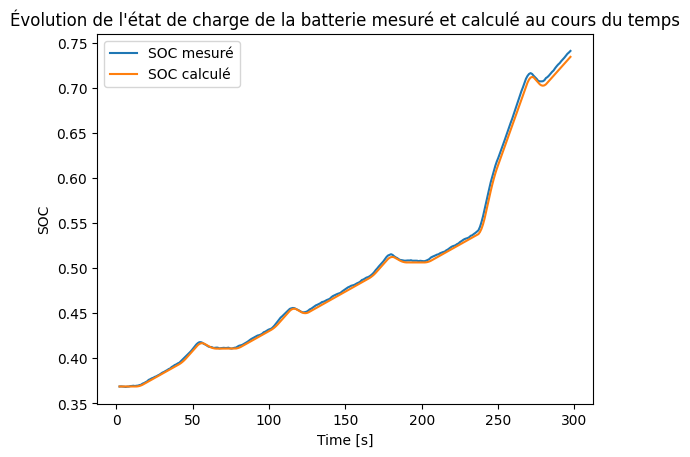

In [ ]:
SOC_calcule = [SOC[0]] 
for i in range(len(df) - 1):
    delta_Q = (d_t * beta * U * I[i]) / Q_barre
    nouveau_soc = SOC_calcule[-1] + delta_Q
    SOC_calcule.append(nouveau_soc)

plt.plot(df['Time [s]'], list(SOC), label='SOC mesuré')
plt.plot(df['Time [s]'], SOC_calcule, label='SOC calculé')
plt.xlabel('Time [s]')
plt.ylabel('SOC')
plt.legend()
plt.title('Évolution de l\'état de charge de la batterie mesuré et calculé au cours du temps')
plt.show()

Nous avons utilisé un filtrage par moyenne mobile (avec une fenêtre de cinq points).
Ce filtre permet de lisser les bruits de mesure (i.e. les fluctuations aléatoires du capteur), en prenant pour valeurs de la *dataframe* utilisée les moyennes glissantes de cinq valeurs consécutives de la *dataframe* originale.
Cela permet :

- D'une part, à l'algorithme des moindres carrés de ne pas être trop influencé par les écarts de mesure ponctuels du capteur, en limitant l'impact qu'ils ont sur l'écart quadratique. C'est d'autant plus important que le modèle repose sur le calcul de la variation de l'état de charge.

- D'autre part, aux graphiques d'être plus lisses, i.e. de ne pas présenter de dents de scie dues aux bruits de mesure.

# 3. Étude et résolution numérique du problème centralisé #
**Question 6 :** Quelles méthodes de résolution peuvent être envisagées pour ce problème ?

**Réponse :**

**Question 7 :** Développer un algorithme de résolution dans le cas d’un horizon de temps de $24h \: (t_{0} = 17h, ∆t =
0.25h)$, avec :
$\newline$
• un tarif d’heure creuse ($c_{i} = c_{cr}$ constant) entre d’une part minuit et $6h$, et d’autre part $12h$ et $14h$
et un tarif d’heure pleine ($c_{i} = c_{pl}$ constant) le reste du temps ;
$\newline$
• un premier véhicule qui arrive avec un état de charge de $30\%$ à $18h$ et souhaite repartir à $8h$ le
lendemain matin ;
$\newline$
• un second véhicule qui arrive avec un état de charge de $50\%$ à $18h30$ et souhaite repartir à $9h$ le
lendemain.
$\newline$
On prendra les valeurs numériques suivantes :
$\newline$
$$c_{cr} = 1 , c_{pl} = 3/2 , \bar{Q} = 50Ah , \bar{P} = 2.5kW \tag{6}$$
$\newline$
On veillera à afficher au minimum les graphiques suivants :$\newline$
(a) l’évolution de l’état de charge de chaque véhicule au cours du temps ainsi que la puissance (normalisée) fournie à chaque véhicule. On prendra soin d’indiquer les temps de contrainte de pleine
charge des véhicules.
$\newline$
(b) l’évolution de la puissance totale (normalisée) fournie à la flotte, au cours du temps, ainsi que
celle du tarif électrique.
$\newline$
Commenter les résultats obtenus.

**Réponse :**

Running HiGHS 1.10.0 (git hash: fd866539): Copyright (c) 2025 HiGHS under MIT licence terms
LP   has 286 rows; 384 cols; 762 nonzeros
Coefficient ranges:
  Matrix [2e-02, 1e+00]
  Cost   [2e-01, 4e-01]
  Bound  [3e-01, 2e+00]
  RHS    [2e+00, 2e+00]
Presolving model
165 rows, 222 cols, 438 nonzeros  0s
113 rows, 170 cols, 334 nonzeros  0s
82 rows, 139 cols, 272 nonzeros  0s
60 rows, 117 cols, 228 nonzeros  0s
Dependent equations search running on 2 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
55 rows, 108 cols, 214 nonzeros  0s
Presolve : Reductions: rows 55(-231); columns 108(-276); elements 214(-548)
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 0s
         33     2.1462201008e+01 Pr: 0(0); Du: 0(2.22045e-15) 0s
Solving the original LP from the solution after postsolve
Model status        :

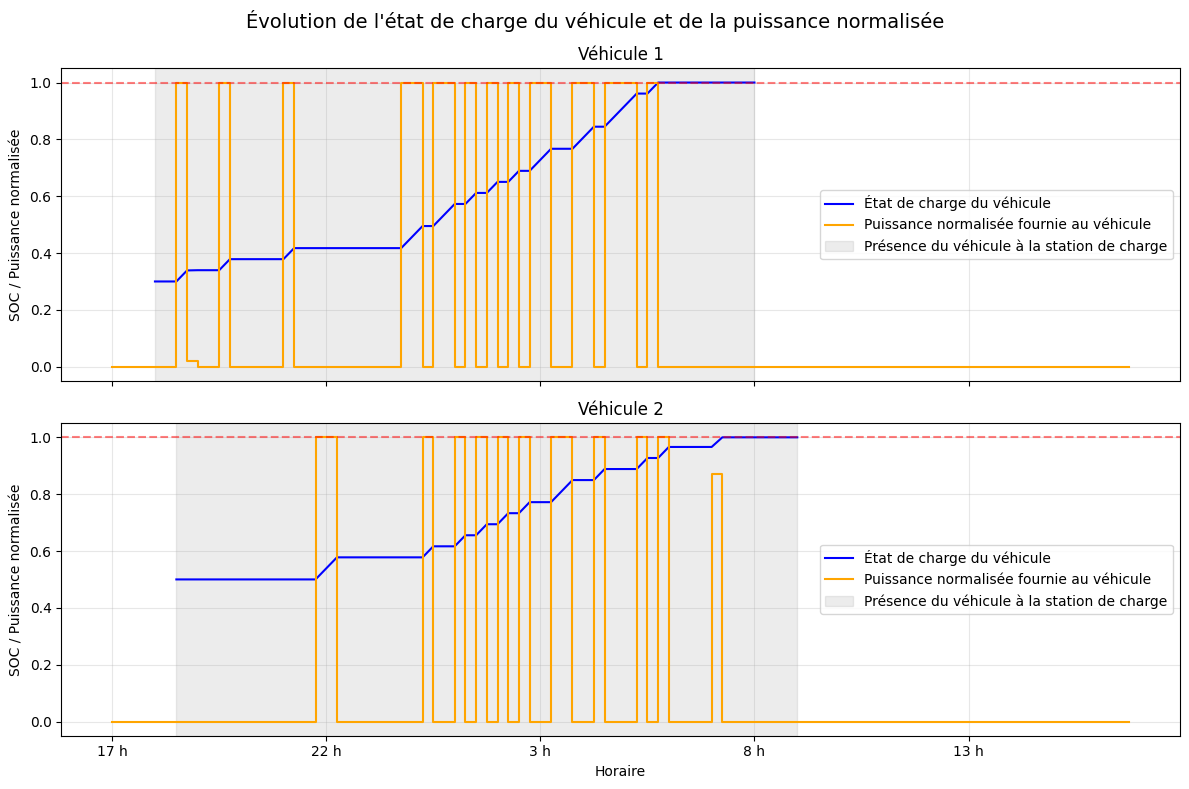

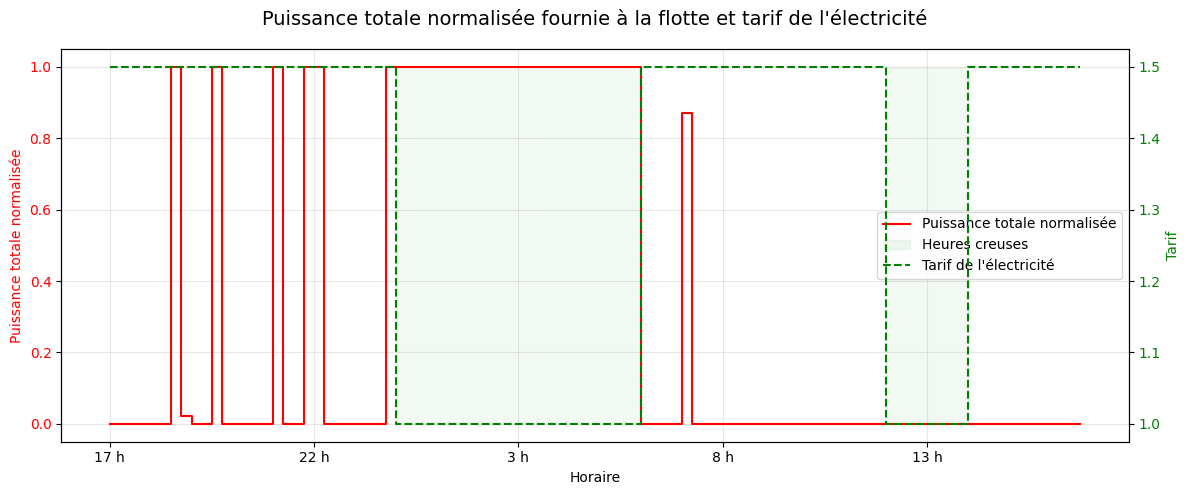

(array([[ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  2.5       ,  0.05231268,  0.        ,  0.        ,
          2.5       ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  2.5       ,  0.        ,  0.        , -0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  2.5       ,  2.5       , -0.        ,
          2.5       ,  2.5       , -0.        ,  2.5       , -0.        ,
          2.5       , -0.        ,  2.5       , -0.        ,  2.5       ,
          2.5       , -0.        ,  0.        ,  2.5       ,  2.5       ,
         -0.        ,  2.5       ,  2.5       ,  2.5       ,  0.        ,
          2.5       , -0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.

In [ ]:
def solve_pb_centralise():

    ## Données générales
    t_tot = 24 # h
    t_0 = 17 # h
    delta_t = 0.25 # h
    c_cr = 1
    c_pl = 3/2
    Q_bar = 50 # Ah
    P_bar = 2.5 # kW
    N_v = 2
    h_arr = [18, 18.5] # h
    h_dep = [8, 9] # h
    SOC_in = [0.3, 0.5]
# beta défini en Q5

    assert (t_tot <= 24)
    assert(len(h_arr) == len(h_dep) == len(SOC_in) == N_v)

    ## Variables utiles
    N = int(t_tot/delta_t)
    temps_cumule = np.linspace(t_0, t_0 + t_tot, N, endpoint=False)
    heure_reelle = np.mod(temps_cumule, 24)
    prix = np.where(((heure_reelle >= 0) & (heure_reelle < 6)) | ((heure_reelle >= 12) & (heure_reelle < 14)), c_cr, c_pl)

    P = ca.SX.sym('P', N_v, N)
    SOC = ca.SX.sym('SOC', N_v, N)
    x = ca.vertcat(ca.reshape(P, N_v*N, 1), ca.reshape(SOC, N_v*N, 1))

    cout = delta_t * ca.sum(P @ prix.reshape(N, 1))

    g = []
    lbg = []
    ubg = []

    coeff_multip = delta_t * beta * 1000 / Q_bar

    for j in range(N_v):
        for i in range(N-1):
            g.append(SOC[j, i+1] - (SOC[j, i] + coeff_multip * P[j, i]))
            lbg.append(0.0)
            ubg.append(0.0)

    P_lb = np.zeros((N_v, N))
    P_ub = np.zeros((N_v, N))
    SOC_lb = np.zeros((N_v, N))
    SOC_ub = np.ones((N_v, N))

    for i in range(N):
        P_tot = ca.sum1(P[:, i])
        g.append(P_tot)
        lbg.append(0.0)
        ubg.append(P_bar)
    
    g = ca.vertcat(*g)

    for j in range(N_v):
        h_arr_cumule = h_arr[j] if h_arr[j] >= t_0 else h_arr[j] + 24
        h_dep_cumule = h_dep[j] if h_dep[j] >= h_arr[j] else h_dep[j] + 24
        
        id_arr = int(np.round((h_arr_cumule - t_0) / delta_t))
        id_dep = int(np.round((h_dep_cumule - t_0) / delta_t)) - 1
        SOC_lb[j, :id_arr+1] = SOC_in[j]
        SOC_ub[j, :id_arr+1] = SOC_in[j]
        SOC_lb[j, id_dep:] = 1.0
        
        for i in range(N):
            t_courant = temps_cumule[i]
            
            if t_courant >= h_arr_cumule and t_courant < h_dep_cumule:
                P_ub[j, i] = P_bar
    
    lbx = np.concatenate((P_lb.flatten(order='F'), SOC_lb.flatten(order='F')))
    ubx = np.concatenate((P_ub.flatten(order='F'), SOC_ub.flatten(order='F')))

    lp = {'x': x, 'f': cout, 'g': g}
    solver = ca.qpsol('solver', 'highs', lp)
    sol = solver(lbx=lbx, ubx=ubx, lbg=lbg, ubg=ubg)

    ## Résultats et affichage

    x_opt = np.array(sol['x'])
    P_opt = x_opt[:N_v*N].reshape((N_v, N), order='F')
    SOC_opt = x_opt[N_v*N:].reshape((N_v, N), order='F')

    P_normal = P_opt / P_bar
    P_tot_normal = np.sum(P_normal, axis=0)

    ## Figure (a)
    fig_a, axes = plt.subplots(N_v, 1, figsize=(12, 8), sharex=True)
    
    for j in range(N_v):
        ax = axes[j]
        
        h_arr_cumule = h_arr[j] if h_arr[j] >= t_0 else h_arr[j] + 24
        h_dep_cumule = h_dep[j] if h_dep[j] >= h_arr[j] else h_dep[j] + 24
    
        SOC_opt_pres = SOC_opt[j, :].copy()
        SOC_opt_pres[(temps_cumule < h_arr_cumule) | (temps_cumule > h_dep_cumule)] = np.nan

        ax.plot(temps_cumule, SOC_opt_pres, label='État de charge du véhicule', color='blue')
        ax.step(temps_cumule, P_normal[j, :], label='Puissance normalisée fournie au véhicule', color='orange', where='post')
        
        ax.axvspan(h_arr_cumule, h_dep_cumule, color='gray', alpha=0.15, label='Présence du véhicule à la station de charge')
        
        ax.axhline(1.0, color='red', linestyle='--', alpha=0.5)

        ax.set_ylabel('SOC / Puissance normalisée')
        ticks_loc = np.arange(t_0, t_0 + t_tot, 5)
        ax.set_xticks(ticks_loc)
        ax.set_xticklabels([f"{int(t % 24)} h" for t in ticks_loc])
        ax.set_title(f'Véhicule {j+1}')
        ax.legend()
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel('Horaire')
    fig_a.suptitle('Évolution de l\'état de charge du véhicule et de la puissance normalisée', fontsize=14)
    plt.tight_layout()
    plt.show()

    ## Figure (b)
    fig_b, ax1 = plt.subplots(figsize=(12, 5))

    ax1.step(temps_cumule, P_tot_normal, label='Puissance totale normalisée', color='red', where='post')
    ax1.set_xlabel('Horaire')
    ax1.set_ylabel('Puissance totale normalisée', color='red')
    ticks_loc = np.arange(t_0, t_0 + t_tot, 5)
    ax1.set_xticks(ticks_loc)
    ax1.set_xticklabels([f"{int(t % 24)} h" for t in ticks_loc])
    ax1.tick_params(axis='y', labelcolor='red')
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.step(temps_cumule, prix, label='Tarif de l\'électricité', color='green', linestyle='--', where='post')
    ax2.set_ylabel('Tarif', color='green')
    ax2.tick_params(axis='y', labelcolor='green')

    fill = [True if prix[i] == c_cr or (i !=0 and prix[i-1] == c_cr) else False for i in range(len(prix))]

    ax1.fill_between(temps_cumule, min(P_tot_normal), max(P_tot_normal), where=fill, color='green', alpha=0.05, step='post', label='Heures creuses')

    fig_b.suptitle('Puissance totale normalisée fournie à la flotte et tarif de l\'électricité', fontsize=14)
    
    handles_1, labels_1 = ax1.get_legend_handles_labels()
    handles_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(handles_1 + handles_2, labels_1 + labels_2)

    plt.tight_layout()
    plt.show()
    
    return P_opt, SOC_opt

solve_pb_centralise()

Commentons ces résultats :

- **Les contraintes sont respectées** : les deux véhicules partent avec une batterie pleinement chargée à l'heure souhaitée, et la puissance totale fournie à la flotte ne dépasse jamais la puissance maximale de la station de charge.

- **La solution semble optimale** : la borne fonctionne à pleine puissance pendant les heures creuses (c'est-à-dire sur la fenêtre tarifaire la plus avantageuse), ce qui est intuitivement un comportement.

- **Les horaires de charge pendant les heures pleines semblent arbitraires** : la charge "manquante" est complétée pendant les heures pleines, mais elle est "hachée", car du point de vue du solveur, tous les créneaux horaires de charge sur les heures pleines se valent. Ces créneaux sont donc choisis de façon apparemment arbitraire, sans souci de continuité de la charge.

**Question 8:** Quels inconvénients présente cette solution centralisée ? (On pourra penser aux données dont doit
disposer l’optimiseur pour la résolution.)

**Réponse :**